# Tutorial 06: End-to-End DRP Pipeline

This tutorial demonstrates the complete AMASE-P DRP workflow from raw detector images to uncalibrated fiber spectra.

**Pipeline stages covered:**
1. **Image Preprocessing** — bias subtraction, dark subtraction, pixel flat-field correction
2. **Fiber Identification & Tracing** — detect fiber blocks and model trace curvature
3. **Spectral Extraction** — convert 2-D images into 1-D row-stacked spectra (`FiberFrame`)

We use synthetic data so the notebook is fully self-contained and reproducible without external data files.

In [1]:
import os
import shutil
import tempfile

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from amasedrp.preprocessing import Image, image_preprocessing
from amasedrp.reduction import identify_and_trace_fibers, extract_spectra
from amasedrp.utils.logging import configure_logging
from amasedrp.visualization import plot_fits_image

## 1. Setup & Logging

Create a temporary working directory and configure file-based logging so every pipeline step is recorded.

In [2]:
# Create a temporary workspace
tmp_dir = "./test/"
# tmp_dir = tempfile.mkdtemp(prefix="amase_e2e_demo_")
log_path = os.path.join(tmp_dir, "pipeline.log")

# Configure logging: all amasedrp modules will write INFO+ messages to this file
configure_logging(
    log_file=log_path,
    level=__import__("logging").INFO,
    fmt="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
)

print("Working directory:", tmp_dir)
print("Log file       :", log_path)

Working directory: ./test/
Log file       : ./test/pipeline.log


## 2. Generate Synthetic Raw Data

We simulate a complete observation set: master bias, master dark, pixel flat, fiber flat, and a science frame.

All images include realistic detector effects (bias level, dark current, pixel-response variation, and read noise).

In [3]:
def synthetic_fiber_image(n_rows=512, n_blocks=3, n_fibers_per_block=5,
                          fiber_sigma=2.5, fiber_spacing=15, block_gap=100):
    """Create an ideal fiber-flat image with Gaussian fiber profiles."""
    fiber_profile_width = int(6 * fiber_sigma)
    block_width = n_fibers_per_block * fiber_spacing + fiber_profile_width
    n_cols = n_blocks * block_width + (n_blocks - 1) * block_gap
    image = np.zeros((n_rows, n_cols), dtype=np.float64)
    x = np.arange(n_cols)
    col_offset = fiber_profile_width // 2
    for b in range(n_blocks):
        for f in range(n_fibers_per_block):
            center = col_offset + f * fiber_spacing
            profile = np.exp(-0.5 * ((x - center) / fiber_sigma) ** 2)
            image += profile[np.newaxis, :]
        col_offset += block_width + block_gap
    return image


# --- detector parameters ---
gain = 1.0                    # e- / ADU
dark_current_adu = 0.5        # ADU per second
rng = np.random.default_rng(42)

# --- image geometry ---
n_rows = 512
n_blocks = 3
n_fibers_per_block = 5
fiber_sigma = 2.5
fiber_spacing = 15
block_gap = 100

fiber_profile_width = int(6 * fiber_sigma)
block_width = n_fibers_per_block * fiber_spacing + fiber_profile_width
n_cols = n_blocks * block_width + (n_blocks - 1) * block_gap
shape = (n_rows, n_cols)

# Spatial gradient in pixel response (for pixflat demonstration)
x_grad = np.linspace(0.95, 1.05, n_cols)

# 1. Master Bias
bias_data = np.full(shape, 100.0, dtype=np.float32)
bias_hdr = fits.Header()
bias_hdr["IMAGETYP"] = "bias"
bias_hdr["GAIN"] = gain
bias_path = os.path.join(tmp_dir, "bias.fits")
fits.PrimaryHDU(bias_data, header=bias_hdr).writeto(bias_path, overwrite=True)

# 2. Master Dark
dark_exptime = 60.0
dark_data = np.full(shape, 100.0 + dark_current_adu * dark_exptime, dtype=np.float32)
dark_hdr = fits.Header()
dark_hdr["IMAGETYP"] = "dark"
dark_hdr["EXPTIME"] = dark_exptime
dark_hdr["GAIN"] = gain
dark_path = os.path.join(tmp_dir, "dark.fits")
fits.PrimaryHDU(dark_data, header=dark_hdr).writeto(dark_path, overwrite=True)

# 3. Master Pixel Flat (with spatial response variation)
pixflat_exptime = 10.0
pixflat_signal = 100.0
pixflat_data = np.full(shape, 0.0, dtype=np.float32)
pixflat_data[:] = pixflat_signal * x_grad[np.newaxis, :] + 100.0 + dark_current_adu * pixflat_exptime
pixflat_hdr = fits.Header()
pixflat_hdr["IMAGETYP"] = "flat"
pixflat_hdr["EXPTIME"] = pixflat_exptime
pixflat_hdr["GAIN"] = gain
pixflat_path = os.path.join(tmp_dir, "pixflat.fits")
fits.PrimaryHDU(pixflat_data, header=pixflat_hdr).writeto(pixflat_path, overwrite=True)

# 4. Fiber Flat (raw)
ideal_flat = synthetic_fiber_image(n_rows, n_blocks, n_fibers_per_block)
ideal_flat = ideal_flat / ideal_flat.max() * 500.0   # peak ~500 ADU
flat_exptime = 10.0
raw_flat = (
    ideal_flat * x_grad[np.newaxis, :]
    + 100.0
    + dark_current_adu * flat_exptime
    + rng.normal(0, 2.0, shape)
).astype(np.float32)
flat_hdr = fits.Header()
flat_hdr["IMAGETYP"] = "flat"
flat_hdr["EXPTIME"] = flat_exptime
flat_hdr["GAIN"] = gain
flat_path = os.path.join(tmp_dir, "fiberflat.fits")
fits.PrimaryHDU(raw_flat, header=flat_hdr).writeto(flat_path, overwrite=True)

# 5. Science Frame (raw)
# Add spectral modulation along the dispersion (row) direction
spectral_mod = 1.0 + 0.2 * np.sin(np.linspace(0, 4 * np.pi, n_rows))[:, np.newaxis]
ideal_sci = ideal_flat * spectral_mod
sci_exptime = 30.0
raw_sci = (
    ideal_sci * x_grad[np.newaxis, :]
    + 100.0
    + dark_current_adu * sci_exptime
    + rng.normal(0, 2.0, shape)
).astype(np.float32)
sci_hdr = fits.Header()
sci_hdr["IMAGETYP"] = "object"
sci_hdr["EXPTIME"] = sci_exptime
sci_hdr["GAIN"] = gain
sci_path = os.path.join(tmp_dir, "science.fits")
fits.PrimaryHDU(raw_sci, header=sci_hdr).writeto(sci_path, overwrite=True)

print(f"Generated {n_blocks} blocks x {n_fibers_per_block} fibers = {n_blocks * n_fibers_per_block} total fibers")
print(f"Image shape: {shape}")

Generated 3 blocks x 5 fibers = 15 total fibers
Image shape: (512, 470)


## 3. Stage 1 — Image Preprocessing

Calibrate both the fiber-flat and the science frame using the master calibration files.

Standard calibration equation applied internally:

```
dark_curr = (dark - bias) / dark_exptime
pixresp   = [(pixflat - bias) - dark_curr * pixflat_exptime] / median(...)
calibrated = [(science - bias) - dark_curr * science_exptime] / pixresp
```

In [4]:
# Preprocess the fiber flat
cal_flat_path = os.path.join(tmp_dir, "cal_flat.fits")
cal_flat = image_preprocessing(
    input_path=flat_path,
    bias_path=bias_path,
    dark_path=dark_path,
    pixflat_path=pixflat_path,
    output_path=cal_flat_path,
    log_file=log_path,
)

# Preprocess the science frame
cal_sci_path = os.path.join(tmp_dir, "cal_sci.fits")
cal_sci = image_preprocessing(
    input_path=sci_path,
    bias_path=bias_path,
    dark_path=dark_path,
    pixflat_path=pixflat_path,
    output_path=cal_sci_path,
    log_file=log_path,
)

print("Calibrated flat  shape:", cal_flat.shape)
print("Calibrated science shape:", cal_sci.shape)

Calibrated flat  shape: (512, 470)
Calibrated science shape: (512, 470)


/home/zeng/code/amase/amasedrp/src/amasedrp/preprocessing/core/image.py:47: UserWarning: Image data contains negative values, which may indicate an issue with the data or the gain value.
  warnings.warn(


## 4. Stage 2 — Fiber Identification & Tracing

Use the calibrated fiber-flat image to detect fiber blocks, identify individual fibers, and fit a polynomial trace model for each fiber.

In [5]:
fibermap, tracemask = identify_and_trace_fibers(
    image=cal_flat.data,
    n_blocks_expected=n_blocks,
    n_fibers_per_block_expected=n_fibers_per_block,
)

print(f"Detected {fibermap.n_fibers} fibers across {n_blocks} block(s).")
print(f"TraceMask polynomial degree: {tracemask.coeffs.shape[1] - 1}")

Detected 15 fibers across 3 block(s).
TraceMask polynomial degree: 10


## 5. Stage 3 — Spectral Extraction

Extract 1-D spectra from the calibrated science image using the trace model derived above.

We use **boxcar extraction** (aperture sum) — fast, robust, and sufficient for uncalibrated spectra.

In [6]:
frame = extract_spectra(
    image=cal_sci.data,
    tracemask=tracemask,
    fibermap=fibermap,
    method="boxcar",
    aperture_radius=3,
)

print(f"FiberFrame shape : {frame.shape}")
print(f"Number of fibers : {frame.n_fibers}")
print(f"Wavelength bins  : {frame.n_wave}")
print(f"Flux range       : [{frame.flux.min():.2f}, {frame.flux.max():.2f}]")

FiberFrame shape : (15, 512)
Number of fibers : 15
Wavelength bins  : 512
Flux range       : [2093.82, 3177.95]


## 6. Visualization

Inspect the raw input, the calibrated output, and the extracted spectra.

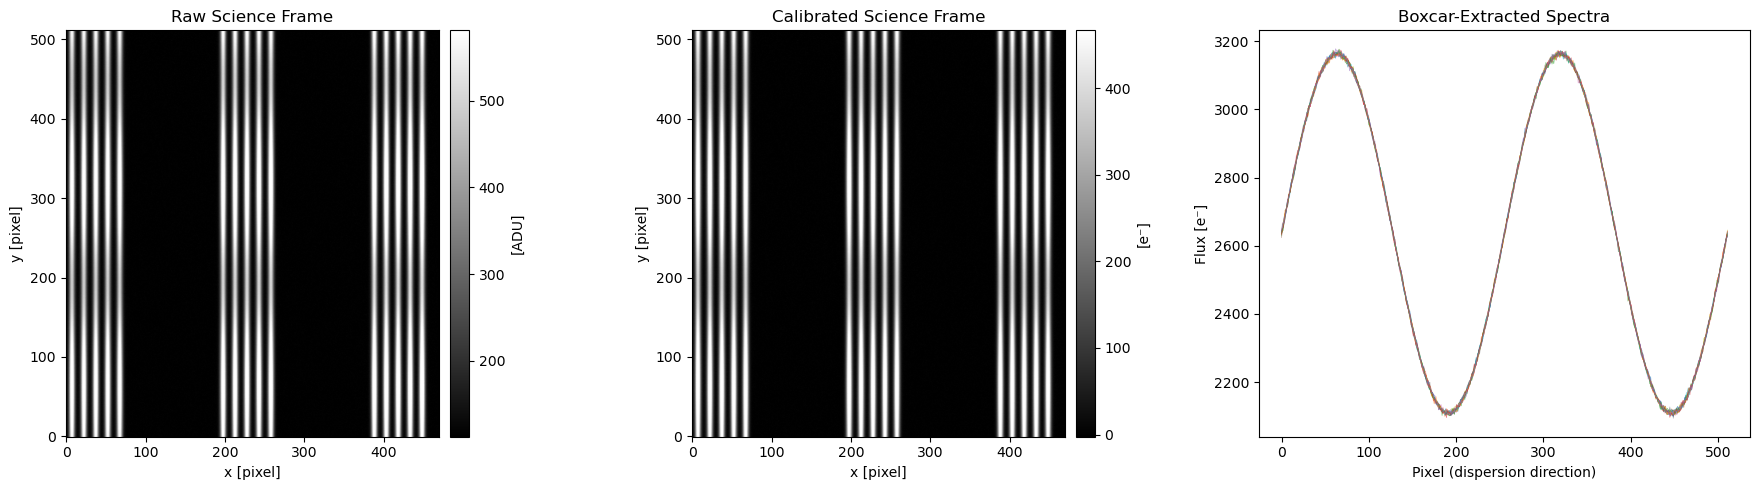

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw science image
ax = axes[0]
ax = plot_fits_image(ax, raw_sci, cmap="gray", draw_colorbar=True, cbar_label="[ADU]")
ax.set_title("Raw Science Frame")
ax.set_xlabel("x [pixel]")
ax.set_ylabel("y [pixel]")

# Calibrated science image
ax = axes[1]
ax = plot_fits_image(ax, cal_sci.data, cmap="gray", draw_colorbar=True, cbar_label="[e⁻]")
ax.set_title("Calibrated Science Frame")
ax.set_xlabel("x [pixel]")
ax.set_ylabel("y [pixel]")

# Extracted spectra (boxcar)
ax = axes[2]
for i in range(frame.n_fibers):
    ax.plot(frame.wave, frame.flux[i], alpha=0.6, lw=0.5)
ax.set_title("Boxcar-Extracted Spectra")
ax.set_xlabel("Pixel (dispersion direction)")
ax.set_ylabel("Flux [e⁻]")

plt.tight_layout()
plt.show()

## 7. Save Pipeline Products

Write the calibrated image and the extracted `FiberFrame` to FITS files for downstream processing (e.g., wavelength calibration, sky subtraction, flux calibration).

In [8]:
# Save the preprocessed science image
preproc_output = os.path.join(tmp_dir, "preprocessed_science.fits")
cal_sci.write_to_fits(preproc_output)
print("Preprocessed image saved to:", preproc_output)

# Save the extracted FiberFrame
rss_output = os.path.join(tmp_dir, "uncalibrated_spectra.fits")
frame.to_fits(rss_output, overwrite=True)
print("Uncalibrated spectra saved to:", rss_output)

Preprocessed image saved to: ./test/preprocessed_science.fits
Uncalibrated spectra saved to: ./test/uncalibrated_spectra.fits


## 8. Inspect the Pipeline Log

All INFO-level messages from the preprocessing steps have been accumulated in the log file.

In [9]:
with open(log_path, "r") as f:
    print(f.read())

2026-06-29 09:49:56,922 [INFO] amasedrp.preprocessing.image_preprocessing: Applying bias calibration...
2026-06-29 09:49:56,922 [INFO] amasedrp.preprocessing.image_preprocessing: bias calibration applied.
2026-06-29 09:49:56,922 [INFO] amasedrp.preprocessing.image_preprocessing: Applying dark calibration...
2026-06-29 09:49:56,922 [INFO] amasedrp.preprocessing.image_preprocessing: dark calibration applied.
2026-06-29 09:49:56,922 [INFO] amasedrp.preprocessing.image_preprocessing: Applying pixflat calibration...
2026-06-29 09:49:56,923 [INFO] amasedrp.preprocessing.image_preprocessing: pixflat calibration applied.
2026-06-29 09:49:56,926 [INFO] amasedrp.preprocessing.image_preprocessing: Applying bias calibration...
2026-06-29 09:49:56,926 [INFO] amasedrp.preprocessing.image_preprocessing: bias calibration applied.
2026-06-29 09:49:56,926 [INFO] amasedrp.preprocessing.image_preprocessing: Applying dark calibration...
2026-06-29 09:49:56,926 [INFO] amasedrp.preprocessing.image_preprocess

## 9. Cleanup

Remove the temporary working directory (optional — comment out if you want to keep the products).

In [10]:
# shutil.rmtree(tmp_dir)
# print("Cleaned up temporary workspace.")

## Summary

This tutorial walked through the complete AMASE-P DRP pipeline from raw images to uncalibrated spectra:

| Step | Function / Module | Output |
|------|-------------------|--------|
| Raw data generation | `astropy.io.fits` + synthetic functions | FITS files |
| Image preprocessing | `amasedrp.preprocessing.image_preprocessing` | Calibrated `Image` |
| Fiber identification | `amasedrp.reduction.identify_and_trace_fibers` | `FiberMap` + `TraceMask` |
| Spectral extraction | `amasedrp.reduction.extract_spectra(method="boxcar")` | `FiberFrame` |
| Product I/O | `Image.write_to_fits`, `FiberFrame.to_fits` | FITS products |
| Logging | `amasedrp.utils.logging.configure_logging` | `pipeline.log` |

**Next steps:** Feed the saved `FiberFrame` into the `amasedrp.calibration` modules for wavelength calibration, sky subtraction, and flux calibration.